In [ ]:
import sys
from hydra import compose, initialize

from utils.synthetic_anomalies import (
    add_event_group,
    reverse_event,
    add_outlier_group,
    add_jump,
    simple_noise_event,
    add_seasonal_cycle_increase,
    add_trend_increase,
)

import matplotlib.pyplot as plt


from utils.data_parsing_tools import load_data_bases

from utils.synthetic_anomalies import detrend_via_model

# I need to build the following: 


- Trend increase ✔
- Var increase ✔
- Event Anomaly 
- Outliers (Mostly important to sanity check the other detection schemes) ✔
- Jump anomaly (Every moves up) ✔

Everything here should be variable in intensity to properly evaluate anomaly dection methods.




In [53]:
with initialize(version_base=None, config_path="../forecasting_analysis/conf/"):
    cfg = compose(config_name="config.yaml", return_hydra_config=True)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [55]:
cfg.dir = "ps"

In [56]:
ps, exogs = load_data_bases(cfg)

Load cached data
Load cached data


In [57]:
data = ps["Lister"]["asc0"]

In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
start = 100
data = ps["Lister"]["asc0"]
data = data[["720593"]]



a = add_trend_increase(
    data,
    increase_start_index=start,
    increase_strength=5,
    nonlinear_trend=True,
    nl_trend_strength=2,
).interpolate()

b = add_seasonal_cycle_increase(
    data, increase_start_index=start, increase_strength=0.1
).interpolate()

c = add_trend_increase(
    add_seasonal_cycle_increase(
        data, increase_start_index=start, increase_strength=0.1
    ).interpolate(),
    increase_start_index=start,
    increase_strength=5,
    nonlinear_trend=True,
    nl_trend_strength=2,
).interpolate()

d = add_event_group(data , reverse_event(data, 100, increase_start_index=start), increase_start_index=start).interpolate()
e = add_jump(data,increase_start_index=start,increase_strength=5).interpolate()

f = add_jump(add_trend_increase(
    data,
    increase_start_index=start,
    increase_strength=2,
    nonlinear_trend=True,
    nl_trend_strength=2,
).interpolate(),increase_start_index=start,increase_strength=5).interpolate()




/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


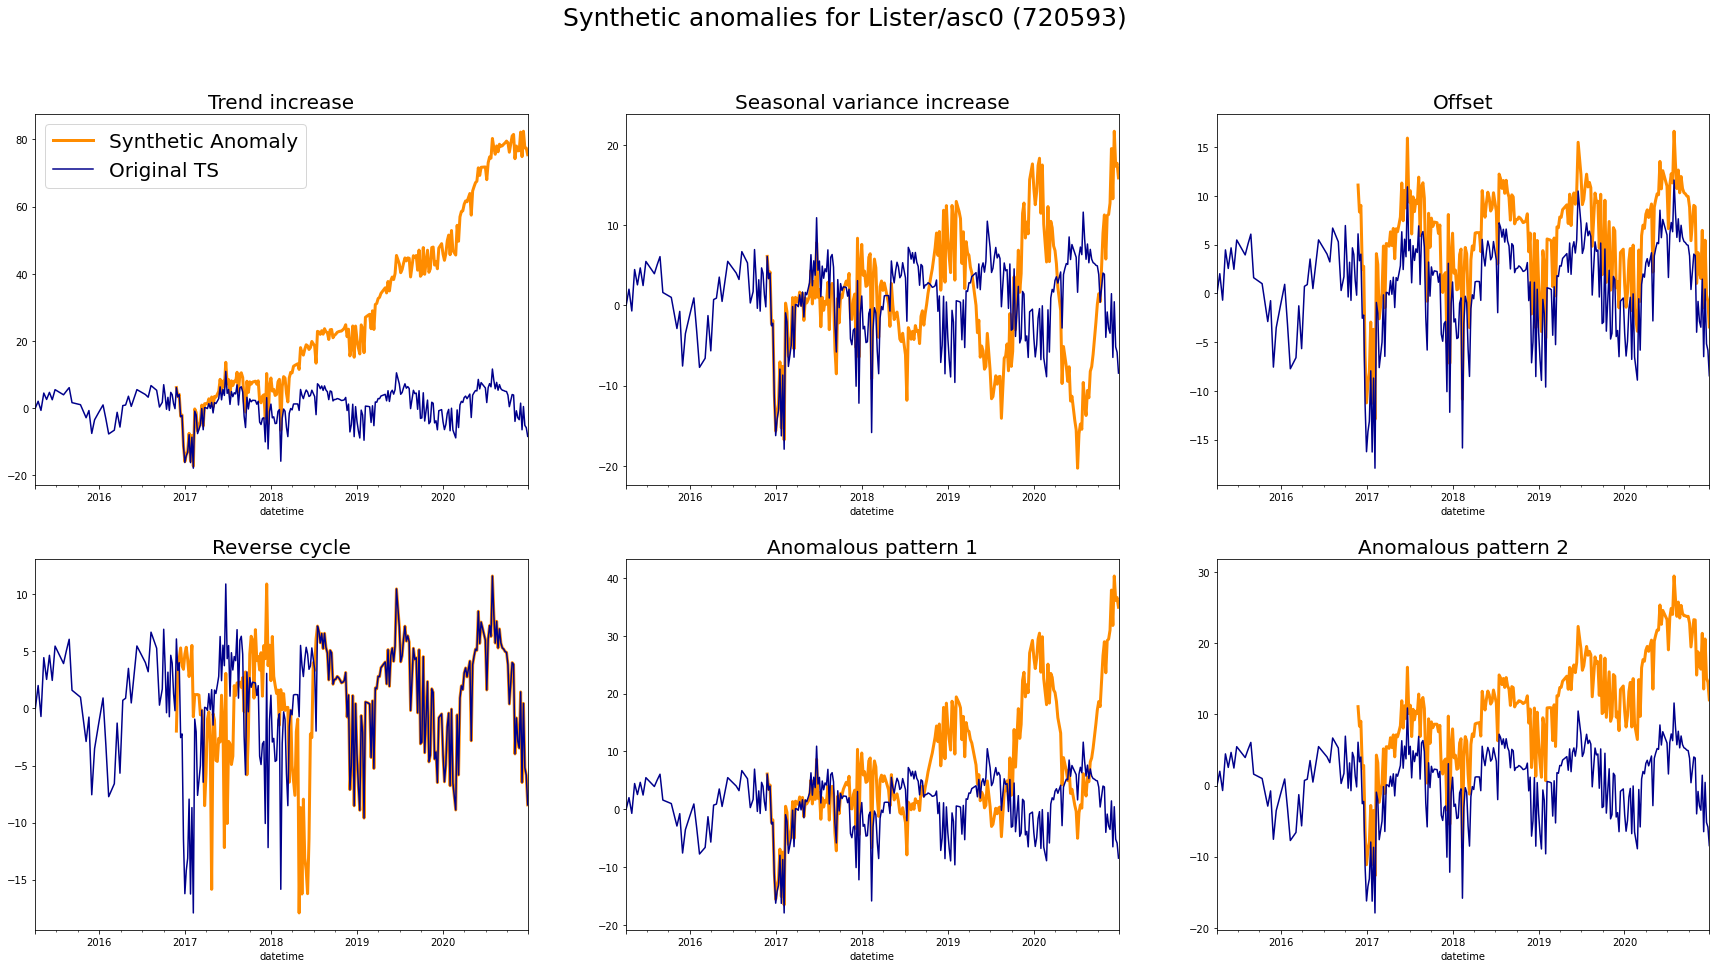

In [107]:
fig, axs = plt.subplots(2, 3, figsize=(30, 15))
fig.suptitle("Synthetic anomalies for Lister/asc0 (720593)", fontsize=25)

variants = [a,b,e,d,c,f]
titles = [
    "Trend increase",
    "Seasonal variance increase",
    "Offset",
    "Reverse cycle",
    "Anomalous pattern 1",
    "Anomalous pattern 2",
]


for n, ax in enumerate(axs.reshape(-1)):
    variants[n].columns = ["Synthetic Anomaly"]
    data.columns = ["Original TS"]
    variants[n][start:].plot(
        label="Synthetic Anomaly", color="darkorange", linewidth=3, ax=ax, legend=False
    )

    data.interpolate().plot(label="Original", color="darkblue", ax=ax, legend=False)
    ax.set_title(titles[n], fontsize=20)

axs[0, 0].legend(fontsize=20)